In [ ]:
!pip install librosa soundfile tqdm -q

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import shutil
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import json
import tarfile
import requests
from google.colab import drive

In [ ]:
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

📂 Mounting Google Drive...
Mounted at /content/drive


In [ ]:
DRIVE_OUTPUT = '/content/drive/MyDrive/InstruNet_ProcessedData'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f"✅ Will save processed data to: {DRIVE_OUTPUT}")

✅ Will save processed data to: /content/drive/MyDrive/InstruNet_ProcessedData


In [ ]:
def download_nsynth_train():
    """
    Download NSynth training set directly to Colab.
    File size: ~70 GB (we'll delete after processing!)
    """

    # NSynth dataset URL (official Google Magenta)
    url = "http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-train.jsonwav.tar.gz"
    output_file = "/content/nsynth-train.jsonwav.tar.gz"
    extract_dir = "/content/nsynth-train"

    # Download with progress bar
    print("Downloading NSYNTH Dataset...")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(output_file, 'wb') as f, tqdm(
        desc="Downloading",
        total=total_size,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            pbar.update(len(chunk))

    print(f"✅ Download complete: {output_file}")

    # Extract tar.gz file
    print("\nExtracting archive...")
    with tarfile.open(output_file, 'r:gz') as tar:
        tar.extractall(path="/content")

    print(f"✅ Extracted to: {extract_dir}")

    # Delete the tar.gz file immediately (save ~70 GB!)
    print(f"\n🗑️  Deleting archive to free space...")
    os.remove(output_file)
    print(f"✅ Freed up ~70 GB!")

    return extract_dir


In [ ]:
def load_nsynth_metadata(dataset_dir):
    """
    Load and parse the examples.json metadata file.
    This tells us which files are acoustic instruments.
    """
    json_path = os.path.join(dataset_dir, "examples.json")
    print(f"\n📋 Loading metadata from: {json_path}")

    with open(json_path, 'r') as f:
        metadata = json.load(f)

    print(f"✅ Loaded metadata for {len(metadata)} audio files")
    return metadata

In [ ]:
def filter_acoustic_instruments(metadata, target_instruments=None, min_samples=500):
    if target_instruments is None:
        target_instruments = [
            'bass', 'brass', 'flute', 'guitar', 'keyboard',
            'mallet', 'organ', 'reed', 'string', 'vocal'
        ]

    print(f"\n🔍 Filtering for acoustic instruments only...")
    print(f"📌 Target families: {target_instruments}")
    print(f"⚖️  Minimum samples required: {min_samples} (prevents class imbalance)")

    filtered_files = {inst: [] for inst in target_instruments}

    for file_id, info in tqdm(metadata.items(), desc="Filtering"):
        # Check if acoustic (source=0) and in target instruments
        if info.get('instrument_source', -1) == 0:  # 0 = acoustic
            family = info.get('instrument_family_str', '')

            if family in target_instruments:
                filtered_files[family].append(file_id)

    # Print initial statistics
    print("\n📊 Initial Filtered Dataset Statistics:")
    total = 0
    for instrument, files in filtered_files.items():
        count = len(files)
        total += count
        print(f"  {instrument:12s}: {count:5d} files")

    # Remove underrepresented classes (CLASS IMBALANCE FIX!)
    print(f"\n⚖️  Checking for class imbalance (min_samples = {min_samples})...")
    removed_classes = []
    balanced_files = {}

    for instrument, files in filtered_files.items():
        if len(files) >= min_samples:
            balanced_files[instrument] = files
            print(f"  ✅ {instrument:12s}: {len(files):5d} files - KEPT")
        else:
            removed_classes.append(instrument)
            print(f"  ❌ {instrument:12s}: {len(files):5d} files - REMOVED (too few samples)")

    if removed_classes:
        print(f"\n🗑️  Removed classes due to insufficient data: {removed_classes}")
        print(f"💡 This prevents the model from performing poorly on underrepresented classes")
    else:
        print(f"\n✅ All classes have sufficient samples!")

    # Final statistics
    print(f"\n📊 Final Balanced Dataset Statistics:")
    total_balanced = 0
    for instrument, files in balanced_files.items():
        count = len(files)
        total_balanced += count
        print(f"  {instrument:12s}: {count:5d} files")

    print(f"\n✅ Total balanced files: {total_balanced}")
    print(f"📉 Removed {total - total_balanced} files from underrepresented classes")

    return balanced_files

In [ ]:
def standardize_audio(file_path, target_sr=22050, duration=3.0):
    """
    Load, resample, convert to mono, and fix duration of audio file.
    """
    try:
        y, sr = librosa.load(file_path, sr=target_sr, mono=True)

        target_length = int(target_sr * duration)

        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        return y, sr
    except Exception as e:
        print(f"⚠️  Error loading {file_path}: {e}")
        return None, None

In [ ]:
def extract_mel_spectrogram(y, sr, n_mels=128, n_fft=2048, hop_length=512, target_shape=(128, 128)):
    """
    Convert audio waveform to Mel-Spectrogram with natural 128x128 fit.

    OPTIMIZED: With 3-second audio, we get ~129 frames naturally.
    We simply trim to 128 instead of interpolating - cleaner and more accurate!

    Args:
        y: Audio time series
        sr: Sample rate
        n_mels: Number of Mel bands (height)
        n_fft: FFT window size
        hop_length: Samples between frames
        target_shape: Final square shape (default: 128x128)

    Returns:
        mel_spec_norm: Normalized square Mel-spectrogram (128x128)
    """
    # Create Mel-Spectrogram (will be 128 x ~129 with 3-second audio)
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )

    # Convert to log scale (decibels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalize to [0, 1]
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())

    # Natural fit: 3 seconds gives ~129 frames, just trim to 128
    # This is MUCH better than interpolating 173→128 (preserves audio quality!)
    if mel_spec_norm.shape[1] > target_shape[1]:
        # Trim excess frames (usually just 1 frame)
        mel_spec_norm = mel_spec_norm[:, :target_shape[1]]
    elif mel_spec_norm.shape[1] < target_shape[1]:
        # Pad if somehow shorter (rare)
        pad_width = target_shape[1] - mel_spec_norm.shape[1]
        mel_spec_norm = np.pad(mel_spec_norm, ((0, 0), (0, pad_width)), mode='constant')

    return mel_spec_norm


In [ ]:
def process_batch(audio_dir, file_ids, instrument, batch_size=500):
    """
    Process files in batches to avoid memory overflow.

    Args:
        audio_dir: Directory containing .wav files
        file_ids: List of file IDs to process
        instrument: Instrument name
        batch_size: Files per batch (500 = ~2GB RAM)

    Returns:
        X_batch: Spectrograms array
        y_batch: Labels array
    """
    X_batch = []
    y_batch = []

    for file_id in tqdm(file_ids[:batch_size], desc=f"Processing {instrument}"):
        file_path = os.path.join(audio_dir, f"{file_id}.wav")

        if not os.path.exists(file_path):
            continue

        # Standardize & Extract
        y, sr = standardize_audio(file_path)
        if y is None:
            continue

        mel_spec = extract_mel_spectrogram(y, sr)

        X_batch.append(mel_spec)
        y_batch.append(instrument)

    return np.array(X_batch), np.array(y_batch)

In [ ]:
def process_filtered_dataset(dataset_dir, filtered_files, drive_output, max_per_class=1000):
    print("\n" + "="*70)
    print("🎵 MILESTONE 1: PROCESSING ACOUSTIC DATASET")
    print("="*70)

    audio_dir = os.path.join(dataset_dir, "audio")

    all_X = []
    all_y = []
    distribution = {}

    for instrument, file_ids in filtered_files.items():
        if len(file_ids) == 0:
            print(f"⚠️  Skipping {instrument}: No files found")
            continue

        # Limit samples per class to manage size
        file_ids = file_ids[:max_per_class]

        print(f"\n📁 Processing {instrument}: {len(file_ids)} files")

        # Process in batches
        X_batch, y_batch = process_batch(audio_dir, file_ids, instrument, batch_size=len(file_ids))

        if len(X_batch) > 0:
            all_X.append(X_batch)
            all_y.append(y_batch)
            distribution[instrument] = len(X_batch)

            print(f"✅ {instrument}: {len(X_batch)} spectrograms created")

    # Concatenate all batches
    print("\n🔗 Concatenating all processed data...")
    X_data = np.concatenate(all_X, axis=0)
    y_labels = np.concatenate(all_y, axis=0)

    print(f"\n📊 Final Dataset:")
    print(f"  Total samples: {len(X_data)}")
    print(f"  Data shape: {X_data.shape}")
    print(f"  Memory size: ~{X_data.nbytes / (1024**3):.2f} GB")

    # Save to Google Drive
    print(f"\n💾 Saving to Google Drive...")
    np.save(os.path.join(drive_output, 'X_data.npy'), X_data)
    np.save(os.path.join(drive_output, 'y_labels.npy'), y_labels)

    # Save distribution info
    with open(os.path.join(drive_output, 'distribution.json'), 'w') as f:
        json.dump(distribution, f, indent=2)

    print(f"✅ Saved to: {drive_output}")

    return X_data, y_labels, distribution

In [ ]:
def cleanup_raw_dataset(dataset_dir):
    """
    Delete the entire raw NSynth dataset to free up space.
    This saves ~70 GB in Colab!
    """
    if os.path.exists(dataset_dir):
        print(f"📂 Deleting: {dataset_dir}")
        print("⏳ This will take 2-3 minutes...")

        shutil.rmtree(dataset_dir)

        print(f"✅ Deleted! Freed up ~70 GB of space")
        print(f"💾 Your processed data is safely stored in Google Drive")
    else:
        print(f"⚠️  Directory not found: {dataset_dir}")

In [ ]:
def visual_audit(X_data, y_labels, n_samples=5):
    """
    Plot random spectrograms from each instrument class.
    """
    instruments = np.unique(y_labels)

    fig, axes = plt.subplots(len(instruments), n_samples,
                            figsize=(15, 3*len(instruments)))

    for i, instrument in enumerate(instruments):
        indices = np.where(y_labels == instrument)[0]
        random_indices = np.random.choice(indices, min(n_samples, len(indices)), replace=False)

        for j, idx in enumerate(random_indices):
            ax = axes[i, j] if len(instruments) > 1 else axes[j]

            librosa.display.specshow(
                X_data[idx],
                ax=ax,
                cmap='viridis',
                x_axis='time',
                y_axis='mel'
            )

            if j == 0:
                ax.set_ylabel(instrument, fontsize=12, fontweight='bold')
            ax.set_title(f'Sample {j+1}')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_distribution(distribution):
    """
    Bar chart showing class balance.
    """
    instruments = list(distribution.keys())
    counts = list(distribution.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(instruments, counts, color='skyblue', edgecolor='navy', linewidth=1.5)

    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{count}', ha='center', fontweight='bold')

    plt.xlabel('Instrument', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
    plt.title('Dataset Distribution (Class Balance Check)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
dataset_dir = download_nsynth_train()
metadata = load_nsynth_metadata(dataset_dir)
filtered_files = filter_acoustic_instruments(
        metadata,
        min_samples=500
    )

Downloading: 100%|██████████| 22.2G/22.2G [02:31<00:00, 158MB/s]
/tmp/ipython-input-1848867919.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


✅ Download complete: /content/nsynth-train.jsonwav.tar.gz

Extracting archive...
✅ Extracted to: /content/nsynth-train

🗑️  Deleting archive to free space...
✅ Freed up ~70 GB!

📋 Loading metadata from: /content/nsynth-train/examples.json
✅ Loaded metadata for 289205 audio files

🔍 Filtering for acoustic instruments only...
📌 Target families: ['bass', 'brass', 'flute', 'guitar', 'keyboard', 'mallet', 'organ', 'reed', 'string', 'vocal']
⚖️  Minimum samples required: 500 (prevents class imbalance)


Filtering: 100%|██████████| 289205/289205 [00:00<00:00, 1294033.10it/s]


📊 Initial Filtered Dataset Statistics:
  bass        :   200 files
  brass       : 12605 files
  flute       :  6362 files
  guitar      : 11380 files
  keyboard    :  8068 files
  mallet      : 26857 files
  organ       :   176 files
  reed        : 13307 files
  string      : 19390 files
  vocal       :  3820 files

⚖️  Checking for class imbalance (min_samples = 500)...
  ❌ bass        :   200 files - REMOVED (too few samples)
  ✅ brass       : 12605 files - KEPT
  ✅ flute       :  6362 files - KEPT
  ✅ guitar      : 11380 files - KEPT
  ✅ keyboard    :  8068 files - KEPT
  ✅ mallet      : 26857 files - KEPT
  ❌ organ       :   176 files - REMOVED (too few samples)
  ✅ reed        : 13307 files - KEPT
  ✅ string      : 19390 files - KEPT
  ✅ vocal       :  3820 files - KEPT

🗑️  Removed classes due to insufficient data: ['bass', 'organ']
💡 This prevents the model from performing poorly on underrepresented classes

📊 Final Balanced Dataset Statistics:
  brass       : 12605 files
  f

In [ ]:
X_data, y_labels, distribution = process_filtered_dataset(
        dataset_dir,
        filtered_files,
        DRIVE_OUTPUT,
        max_per_class=1000  # Limit to 1000 samples per instrument
)


🎵 MILESTONE 1: PROCESSING ACOUSTIC DATASET

📁 Processing brass: 1000 files


Processing brass: 100%|██████████| 1000/1000 [00:33<00:00, 30.12it/s]


✅ brass: 1000 spectrograms created

📁 Processing flute: 1000 files


Processing flute: 100%|██████████| 1000/1000 [00:16<00:00, 60.45it/s]


✅ flute: 1000 spectrograms created

📁 Processing guitar: 1000 files


...

✅ reed: 1000 spectrograms created

📁 Processing string: 1000 files


Processing string: 100%|██████████| 1000/1000 [00:17<00:00, 58.68it/s]


✅ string: 1000 spectrograms created

📁 Processing vocal: 1000 files


Processing vocal: 100%|██████████| 1000/1000 [00:16<00:00, 62.41it/s]


✅ vocal: 1000 spectrograms created

🔗 Concatenating all processed data...

📊 Final Dataset:
  Total samples: 8000
  Data shape: (8000, 128, 128)
  Memory size: ~0.49 GB

💾 Saving to Google Drive...
✅ Saved to: /content/drive/MyDrive/InstruNet_ProcessedData


In [ ]:
cleanup_raw_dataset(dataset_dir)

📂 Deleting: /content/nsynth-train
⏳ This will take 2-3 minutes...
✅ Deleted! Freed up ~70 GB of space
💾 Your processed data is safely stored in Google Drive


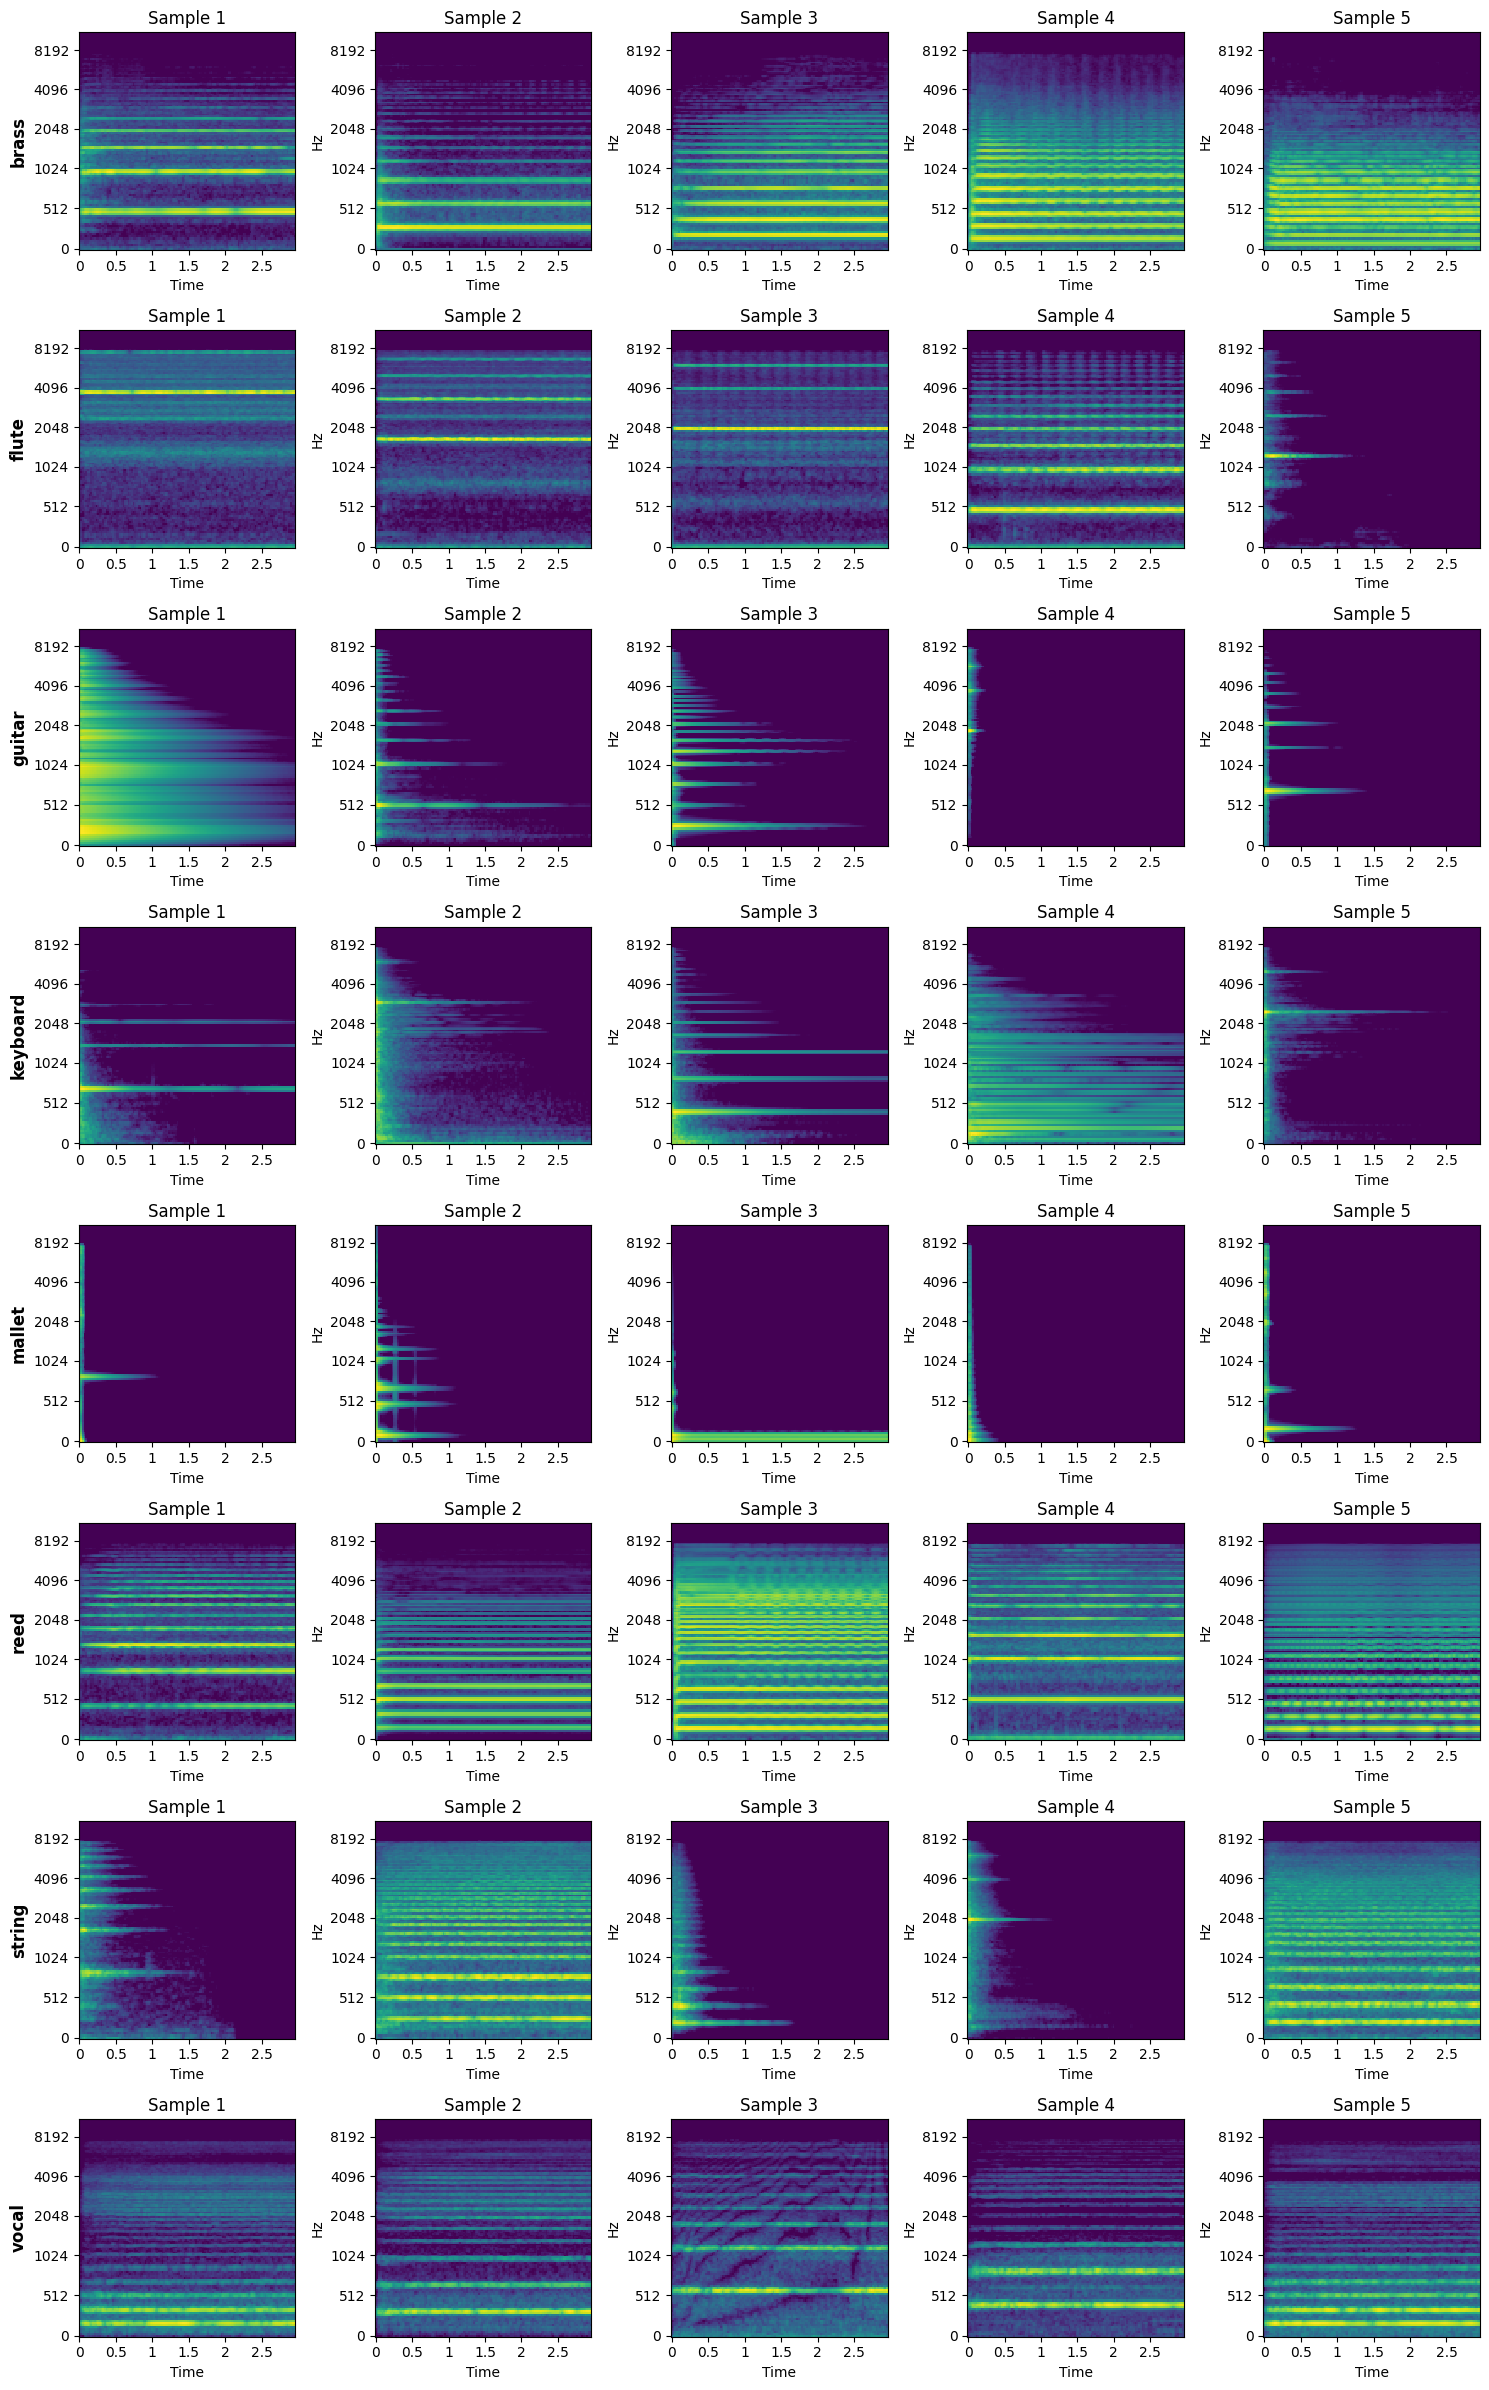

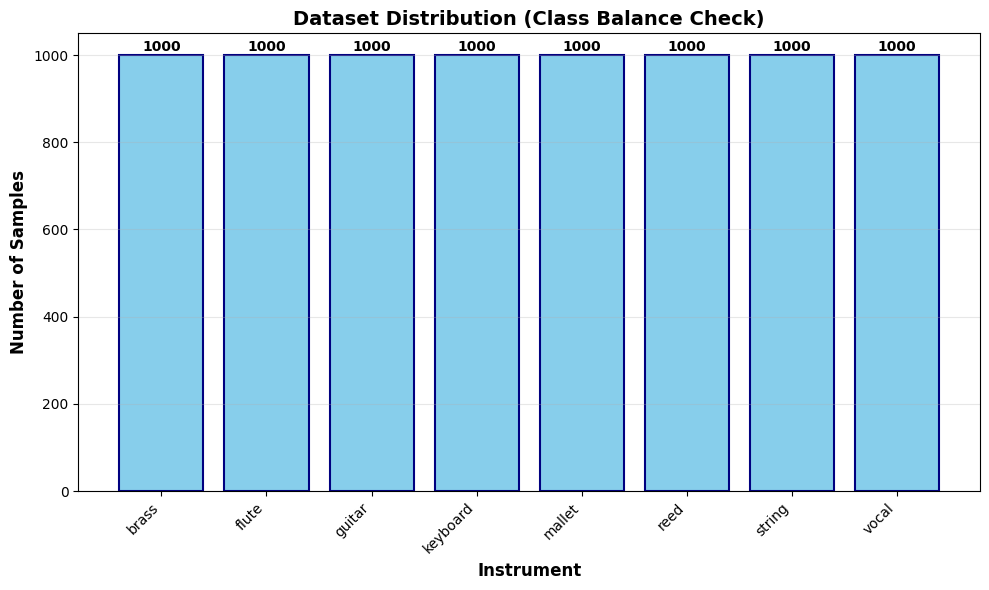

In [ ]:
visual_audit(X_data, y_labels)
plot_distribution(distribution)

In [ ]:
# ============================================================================
# MILESTONE 2:
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

def load_processed_data(drive_output):
    """Load processed data from Google Drive"""
    print(f"\n📂 Loading processed data from Drive...")

    X = np.load(os.path.join(drive_output, 'X_data.npy'))
    y = np.load(os.path.join(drive_output, 'y_labels.npy'))

    print(f"✅ Data loaded!")
    print(f"📐 X shape: {X.shape}")
    print(f"📐 y shape: {y.shape}")

    return X, y

In [ ]:
def prepare_data(X, y, test_size=0.2, random_state=42):
    """Reshape, encode, and split data"""
    # Add channel dimension
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    print(f"✅ Reshaped X: {X.shape}")
    X = X.astype('float32')
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_categorical = to_categorical(y_encoded)

    print(f"✅ Encoded labels: {y_categorical.shape}")
    print(f"📋 Classes: {le.classes_}")

    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_categorical, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    print(f"\n📊 Training samples: {len(X_train)}")
    print(f"📊 Validation samples: {len(X_val)}")

    return X_train, X_val, y_train, y_val, le

In [ ]:
def build_cnn(input_shape, num_classes):
    """Build CNN architecture"""
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),

        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=30, batch_size=32):
    callbacks = [
        # Early Stopping: Stop if val_accuracy doesn't improve for 5 epochs
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,  # Restore weights from best epoch
            verbose=1,
            mode='max'
        ),

        keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(DRIVE_OUTPUT, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1,
            mode='max'
        ),

        # Reduce Learning Rate: Lower LR when stuck
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,  # Reduce LR by half
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    try:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,  # ← Smart training!
            verbose=1,
            shuffle=True
        )

        print("\n Training Complete!")

        # Print best results
        best_epoch = np.argmax(history.history['val_accuracy']) + 1
        best_val_acc = np.max(history.history['val_accuracy'])
        final_val_acc = history.history['val_accuracy'][-1]

        print(f"\nTraining Summary:")
        print(f"   Best validation accuracy: {best_val_acc*100:.2f}% (Epoch {best_epoch})")
        print(f"  Final validation accuracy: {final_val_acc*100:.2f}%")
        print(f"   Best model saved to: {DRIVE_OUTPUT}/best_model.keras")

        return history

    except Exception as e:
        print(f"\n❌ Training failed with error: {e}")
        print("\n🔧 Troubleshooting:")
        print(f"  - X_train shape: {X_train.shape}")
        print(f"  - y_train shape: {y_train.shape}")
        print(f"  - X_train dtype: {X_train.dtype}")
        print(f"  - y_train dtype: {y_train.dtype}")
        raise

In [ ]:
def plot_learning_curves(history):
    """Visualize training progress"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Accuracy', fontweight='bold')
    ax1.set_title('Model Accuracy Over Time', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.set_title('Model Loss Over Time', fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()

    save_path = os.path.join(DRIVE_OUTPUT, 'learning_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Learning curves saved to Drive: {save_path}")
    plt.show()


In [ ]:
def create_confusion_matrix(model, X_val, y_val, label_encoder):
    """Show which instruments get confused"""
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)

    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted', fontweight='bold')
    plt.ylabel('True', fontweight='bold')
    plt.title('Confusion Matrix', fontweight='bold')
    plt.tight_layout()

    save_path = os.path.join(DRIVE_OUTPUT, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ Confusion matrix saved to Drive: {save_path}")
    plt.show()
    print("\n📋 Classification Report:")
    print(classification_report(y_true_classes, y_pred_classes,
                                target_names=label_encoder.classes_))

In [ ]:
X, y = load_processed_data(DRIVE_OUTPUT)
X_train, X_val, y_train, y_val, le = prepare_data(X, y)


📂 Loading processed data from Drive...
✅ Data loaded!
📐 X shape: (8000, 128, 128)
📐 y shape: (8000,)
✅ Reshaped X: (8000, 128, 128, 1)
✅ Encoded labels: (8000, 8)
📋 Classes: ['brass' 'flute' 'guitar' 'keyboard' 'mallet' 'reed' 'string' 'vocal']

📊 Training samples: 6400
📊 Validation samples: 1600


In [ ]:
input_shape = (X_train.shape[1], X_train.shape[2], 1)
num_classes = len(le.classes_)

In [ ]:
model = build_cnn(input_shape, num_classes)
print("\nModel Architecture:")
model.summary()


Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,992 (12.61 MB)

 Trainable params: 3,305,544 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
 history = train_model(model, X_train, y_train, X_val, y_val, epochs=20)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8373 - loss: 0.4622
Epoch 1: val_accuracy improved from -inf to 0.88563, saving model to /content/drive/MyDrive/InstruNet_ProcessedData/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8373 - loss: 0.4620 - val_accuracy: 0.8856 - val_loss: 0.3565 - learning_rate: 0.0010
Epoch 2/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8599 - loss: 0.3899
Epoch 2: val_accuracy did not improve from 0.88563
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8599 - loss: 0.3898 - val_accuracy: 0.8750 - val_loss: 0.3873 - learning_rate: 0.0010
Epoch 3/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8712 - loss: 0.3350
Epoch 3: val_accuracy improved from 0.88563 to 0.89688, saving model to /content/drive/MyDrive/InstruNet_ProcessedData/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8712 - loss: 0.3350 - val_accuracy: 0.8969 - val_loss: 0.3551 - learning_rate: 

In [ ]:
import pickle

DRIVE_OUTPUT = '/content/drive/MyDrive/InstruNet_ProcessedData'

with open(f'{DRIVE_OUTPUT}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ Label encoder saved!")
print(f"Classes: {le.classes_}")

✅ Label encoder saved!
Classes: ['brass' 'flute' 'guitar' 'keyboard' 'mallet' 'reed' 'string' 'vocal']


In [ ]:
# Load best model and evaluate thoroughly
best_model = keras.models.load_model(os.path.join(DRIVE_OUTPUT, 'best_model.keras'))

# Get detailed predictions
y_pred = best_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Per-class metrics
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_true_classes, y_pred_classes, average=None
)

# Identify weak classes
for i, cls in enumerate(le.classes_):
    print(f"{cls:12s}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 405ms/step
brass       : Precision=0.975, Recall=0.975, F1=0.975
flute       : Precision=0.955, Recall=0.965, F1=0.960
guitar      : Precision=0.951, Recall=0.970, F1=0.960
keyboard    : Precision=0.945, Recall=0.950, F1=0.948
mallet      : Precision=0.954, Recall=0.925, F1=0.939
reed        : Precision=0.898, Recall=0.920, F1=0.909
string      : Precision=0.979, Recall=0.950, F1=0.964
vocal       : Precision=1.000, Recall=1.000, F1=1.000


In [ ]:
best_model = keras.models.load_model(os.path.join(DRIVE_OUTPUT, 'best_model.keras'))

In [ ]:
train_loss, train_acc = best_model.evaluate(X_train, y_train, verbose=0)
print(f"\n🎯 Training Set Performance:")
print(f"  Accuracy: {train_acc*100:.2f}%")
print(f"  Loss: {train_loss:.4f}")

# Evaluate on validation set
val_loss, val_acc = best_model.evaluate(X_val, y_val, verbose=0)
print(f"\n🎯 Validation Set Performance:")
print(f"  Accuracy: {val_acc*100:.2f}%")
print(f"  Loss: {val_loss:.4f}")

# Check for overfitting
if train_acc - val_acc > 0.05:
    print(f"\n⚠️ Warning: Potential overfitting detected!")
    print(f"  Training accuracy is {(train_acc - val_acc)*100:.2f}% higher than validation")
else:
    print(f"\n✅ Good generalization! Train-Val gap: {(train_acc - val_acc)*100:.2f}%")


print("\n🔮 Generating predictions...")
y_train_pred = best_model.predict(X_train, verbose=0)
y_val_pred = best_model.predict(X_val, verbose=0)

y_train_pred_classes = np.argmax(y_train_pred, axis=1)
y_train_true_classes = np.argmax(y_train, axis=1)

y_val_pred_classes = np.argmax(y_val_pred, axis=1)
y_val_true_classes = np.argmax(y_val, axis=1)

print("✅ Predictions generated!")


🎯 Training Set Performance:
  Accuracy: 99.69%
  Loss: 0.0129

🎯 Validation Set Performance:
  Accuracy: 95.69%
  Loss: 0.2074

✅ Good generalization! Train-Val gap: 4.00%

🔮 Generating predictions...
✅ Predictions generated!


In [ ]:

from tensorflow import keras
import pickle

# ============================================================================
# DOWNLOAD NSYNTH TEST SET
# ============================================================================

def download_nsynth_test():
    """Download NSynth test set to Colab (4GB)"""
    import tarfile
    import requests
    from tqdm import tqdm

    url = "http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-test.jsonwav.tar.gz"
    output_file = "/content/nsynth-test.tar.gz"
    extract_dir = "/content/nsynth-test"

    # Check if already downloaded
    audio_dir = os.path.join(extract_dir, "audio")
    if os.path.exists(audio_dir):
        print(f"✅ Test set already exists at: {audio_dir}")
        return audio_dir

    print("📥 Downloading NSynth test set (4GB)...")
    print("⏱️ This will take ~2-5 minutes...")

    # Download with progress bar
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(output_file, 'wb') as f, tqdm(
        desc="Downloading",
        total=total_size,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            pbar.update(len(chunk))

    print("✅ Download complete!")

    # Extract
    print("\n📦 Extracting archive...")
    with tarfile.open(output_file, 'r:gz') as tar:
        tar.extractall(path="/content")

    print(f"✅ Extracted to: {extract_dir}")

    # Delete archive to save space
    os.remove(output_file)
    print("🗑️ Deleted archive file (saved 4GB)")

    print(f"\n✅ Test audio files ready at: {audio_dir}")

    return audio_dir

In [ ]:


def filter_acoustic_test_files():
    """
    Filter acoustic instruments from the already downloaded NSynth test set
    and organize them by instrument family.
    """

    # Paths
    test_dir = "/content/nsynth-test"
    audio_dir = os.path.join(test_dir, "audio")
    json_path = os.path.join(test_dir, "examples.json")
    output_dir = "/content/nsynth-test-acoustic"

    # Check if test set exists
    if not os.path.exists(test_dir):
        print("❌ NSynth test set not found!")
        print("Please run the download code first.")
        return None

    print("📂 Loading test set metadata...")

    # Load metadata
    with open(json_path, 'r') as f:
        metadata = json.load(f)

    print(f"✅ Loaded metadata for {len(metadata)} files")

    # Target instruments (same as training)
    target_instruments = ['brass', 'flute', 'guitar', 'keyboard', 'mallet', 'reed', 'string', 'vocal']

    # Filter acoustic files
    print("\n🔍 Filtering acoustic instruments...")
    acoustic_files = {inst: [] for inst in target_instruments}

    for file_id, info in tqdm(metadata.items(), desc="Filtering"):
        # Check if acoustic (source=0) and in target instruments
        if info.get('instrument_source', -1) == 0:  # 0 = acoustic
            family = info.get('instrument_family_str', '')
            if family in target_instruments:
                acoustic_files[family].append(file_id)

    # Show statistics
    print("\n📊 Acoustic files found:")
    total_acoustic = 0
    for instrument, files in acoustic_files.items():
        count = len(files)
        total_acoustic += count
        print(f"   {instrument:12s}: {count:5d} files")

    print(f"\n✅ Total acoustic files: {total_acoustic}")

    # Create organized directory structure
    print("\n📁 Creating organized directory structure...")

    # Create main output directory
    os.makedirs(output_dir, exist_ok=True)

    # Create subdirectories for each instrument
    for instrument in target_instruments:
        inst_dir = os.path.join(output_dir, instrument)
        os.makedirs(inst_dir, exist_ok=True)

    # Copy files to organized folders
    print("\n📋 Copying files to organized folders...")

    for instrument, file_ids in acoustic_files.items():
        if len(file_ids) == 0:
            continue

        inst_dir = os.path.join(output_dir, instrument)

        for file_id in tqdm(file_ids, desc=f"Copying {instrument}"):
            src_file = os.path.join(audio_dir, f"{file_id}.wav")
            dst_file = os.path.join(inst_dir, f"{file_id}.wav")

            if os.path.exists(src_file):
                shutil.copy2(src_file, dst_file)

    print(f"\n✅ Acoustic files organized at: {output_dir}")
    print("\n📂 Directory structure:")
    for instrument in target_instruments:
        inst_dir = os.path.join(output_dir, instrument)
        if os.path.exists(inst_dir):
            num_files = len(os.listdir(inst_dir))
            print(f"   {output_dir}/{instrument}/ → {num_files} files")

    return output_dir

# ============================================================================
# RUN FILTER
# ============================================================================

acoustic_test_dir = filter_acoustic_test_files()

if acoustic_test_dir:
    print("\n" + "="*60)
    print("🎉 SUCCESS!")
    print("="*60)
    print(f"Acoustic test files are now organized in:")
    print(f"{acoustic_test_dir}/")
    print("\nYou can now use these files for testing!")

📂 Loading test set metadata...
✅ Loaded metadata for 4096 files

🔍 Filtering acoustic instruments...


Filtering: 100%|██████████| 4096/4096 [00:00<00:00, 537223.46it/s]



📊 Acoustic files found:
   brass       :   269 files
   flute       :    55 files
   guitar      :   481 files
   keyboard    :   119 files
   mallet      :   202 files
   reed        :   235 files
   string      :   306 files
   vocal       :    22 files

✅ Total acoustic files: 1689

📁 Creating organized directory structure...

📋 Copying files to organized folders...


Copying vocal: 100%|██████████| 22/22 [00:00<00:00, 473.53it/s]


✅ Acoustic files organized at: /content/nsynth-test-acoustic

📂 Directory structure:
   /content/nsynth-test-acoustic/brass/ → 269 files
   /content/nsynth-test-acoustic/flute/ → 55 files
   /content/nsynth-test-acoustic/guitar/ → 481 files
   /content/nsynth-test-acoustic/keyboard/ → 119 files
   /content/nsynth-test-acoustic/mallet/ → 202 files
   /content/nsynth-test-acoustic/reed/ → 235 files
   /content/nsynth-test-acoustic/string/ → 306 files
   /content/nsynth-test-acoustic/vocal/ → 22 files

🎉 SUCCESS!
Acoustic test files are now organized in:
/content/nsynth-test-acoustic/

You can now use these files for testing!


In [ ]:
# Configuration
DRIVE_OUTPUT = '/content/drive/MyDrive/InstruNet_ProcessedData'
ACOUSTIC_TEST_DIR = '/content/nsynth-test-acoustic'

def load_test_model():
    """Load the trained model and label encoder"""
    print("📦 Loading model and label encoder...")
    model = keras.models.load_model(f'{DRIVE_OUTPUT}/best_model.keras')

    with open(f'{DRIVE_OUTPUT}/label_encoder.pkl', 'rb') as f:
        le = pickle.load(f)

    print(f"✅ Model loaded!")
    print(f"📋 Trained classes: {le.classes_}")
    return model, le

def preprocess_audio(file_path, target_sr=22050, duration=3.0):
    """Preprocess audio file same way as training"""
    # Load audio
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Fix duration to 3 seconds
    target_length = int(target_sr * duration)
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode='constant')
    else:
        y = y[:target_length]

    # Create mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512
    )

    # Convert to dB and normalize
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min())

    # Trim to 128x128
    if mel_spec_norm.shape[1] > 128:
        mel_spec_norm = mel_spec_norm[:, :128]
    elif mel_spec_norm.shape[1] < 128:
        pad_width = 128 - mel_spec_norm.shape[1]
        mel_spec_norm = np.pad(mel_spec_norm, ((0, 0), (0, pad_width)), mode='constant')

    # Reshape for model input
    mel_spec_norm = mel_spec_norm.reshape(1, 128, 128, 1)

    return mel_spec_norm

def predict_instrument(model, le, file_path):
    """Predict instrument from audio file"""
    print(f"\n🎵 Testing: {os.path.basename(file_path)}")

    # Preprocess
    X = preprocess_audio(file_path)

    # Predict
    predictions = model.predict(X, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]

    # Get instrument name
    instrument = le.classes_[predicted_class]

    print(f"🎯 Prediction: {instrument.upper()}")
    print(f"💯 Confidence: {confidence*100:.2f}%")

    # Show top 3 predictions
    print(f"\n📊 Top 3 predictions:")
    top_3_idx = np.argsort(predictions[0])[-3:][::-1]
    for idx in top_3_idx:
        print(f"   {le.classes_[idx]:12s}: {predictions[0][idx]*100:.2f}%")

    return instrument, confidence

# ============================================================================
# RUN TESTS
# ============================================================================

# Load model
model, le = load_test_model()

# Check if acoustic test files exist
if not os.path.exists(ACOUSTIC_TEST_DIR):
    print("\n❌ Acoustic test files not found!")
    print("Please run the filter_acoustic_test.py code first to organize test files.")
else:
    print("\n" + "="*60)
    print("🎵 TESTING WITH ACOUSTIC FILES")
    print("="*60)

    # Get statistics
    print("\n📊 Available acoustic test files:")
    total_files = 0
    instrument_counts = {}

    for instrument in le.classes_:
        inst_dir = os.path.join(ACOUSTIC_TEST_DIR, instrument)
        if os.path.exists(inst_dir):
            files = os.listdir(inst_dir)
            instrument_counts[instrument] = len(files)
            total_files += len(files)
            print(f"   {instrument:12s}: {len(files):5d} files")
        else:
            instrument_counts[instrument] = 0
            print(f"   {instrument:12s}:     0 files")

    print(f"\n   Total: {total_files} acoustic test files")

    # Test random files from each instrument
    print("\n" + "="*60)
    print("🧪 TESTING RANDOM FILES FROM EACH INSTRUMENT")
    print("="*60)

    results = {
        'correct': 0,
        'total': 0,
        'per_instrument': {}
    }

    for instrument in le.classes_:
        inst_dir = os.path.join(ACOUSTIC_TEST_DIR, instrument)

        if not os.path.exists(inst_dir) or instrument_counts[instrument] == 0:
            print(f"\n⚠️ No test files for {instrument}")
            continue

        # Get all files for this instrument
        files = os.listdir(inst_dir)

        # Test 3 random files per instrument (or all if less than 3)
        num_tests = min(3, len(files))
        test_files = np.random.choice(files, num_tests, replace=False)

        print(f"\n{'='*60}")
        print(f"Testing {instrument.upper()} ({num_tests} samples)")
        print(f"{'='*60}")

        correct = 0
        for test_file in test_files:
            file_path = os.path.join(inst_dir, test_file)
            predicted_instrument, confidence = predict_instrument(model, le, file_path)

            # Check if correct
            if predicted_instrument.lower() == instrument.lower():
                print("✅ CORRECT!")
                correct += 1
                results['correct'] += 1
            else:
                print(f"❌ INCORRECT (Expected: {instrument.upper()})")

            results['total'] += 1

        # Per-instrument accuracy
        accuracy = (correct / num_tests) * 100
        results['per_instrument'][instrument] = {
            'correct': correct,
            'total': num_tests,
            'accuracy': accuracy
        }

        print(f"\n{instrument.upper()} Accuracy: {correct}/{num_tests} = {accuracy:.1f}%")

    # Final summary
    print("\n" + "="*60)
    print("📊 FINAL RESULTS")
    print("="*60)

    overall_accuracy = (results['correct'] / results['total']) * 100 if results['total'] > 0 else 0

    print(f"\n🎯 Overall Accuracy: {results['correct']}/{results['total']} = {overall_accuracy:.1f}%")

    print(f"\n📋 Per-Instrument Breakdown:")
    for instrument, stats in results['per_instrument'].items():
        print(f"   {instrument:12s}: {stats['correct']}/{stats['total']} = {stats['accuracy']:.1f}%")

    print("\n" + "="*60)

# ============================================================================
# TEST WITH YOUR OWN FILE (OPTIONAL)
# ============================================================================
print("\n📝 To test with your own audio file:")
print("   predict_instrument(model, le, '/path/to/your/file.wav')")

📦 Loading model and label encoder...
✅ Model loaded!
📋 Trained classes: ['brass' 'flute' 'guitar' 'keyboard' 'mallet' 'reed' 'string' 'vocal']

🎵 TESTING WITH ACOUSTIC FILES

📊 Available acoustic test files:
   brass       :   269 files
   flute       :    55 files
   guitar      :   481 files
   keyboard    :   119 files
   mallet      :   202 files
   reed        :   235 files
   string      :   306 files
   vocal       :    22 files

   Total: 1689 acoustic test files

🧪 TESTING RANDOM FILES FROM EACH INSTRUMENT

Testing BRASS (3 samples)

🎵 Testing: brass_acoustic_006-079-050.wav
🎯 Prediction: BRASS
💯 Confidence: 99.92%

📊 Top 3 predictions:
   brass       : 99.92%
   reed        : 0.08%
   flute       : 0.00%
✅ CORRECT!

🎵 Testing: brass_acoustic_046-086-050.wav
🎯 Prediction: BRASS
💯 Confidence: 99.99%

📊 Top 3 predictions:
   brass       : 99.99%
   reed        : 0.01%
   flute       : 0.00%
✅ CORRECT!

🎵 Testing: brass_acoustic_016-065-075.wav
🎯 Prediction: BRASS
💯 Confidence: 1